# **Informe Trabajo Practico de Laboratorio 2**

## Autor: Keila Korj

## Profesor: Mariano Llamedo Soria

## Ayudante de TPs: David Moharos

## ***Introducción***

### **Consigna**

<figure style="text-align: center;">
  <img src="consgina2.png" width="600">
</figure>

### **Objetivo**

El presente trabajo práctico tiene como objetivo el diseño e implementación de filtros digitales sobre la plataforma de desarrollo *STM32F446RE*. El filtro digital en sí mismo es un algoritmo, en nuestro caso para simplificar la tarea vamos a instanciar funciones de la librería de procesamiento digital de arm cmis-dsp:
- arm_fir_f32 
- arm_biquad_cascade_df1_f32

Para llevar a cabo el procesamiento de señales analógicas de manera continua y sin distorsión, , se analiza la cadena completa de adquisición y reconstrucción de la señal:

<figure style="text-align: center;">
  <img src="consigna1.png" alt="Descripción de la imagen" width="600">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 1: Diagrama en bloques de la cadena de procesamiento digital de señales e implementación del filtro en la placa NUCLEO-F446RE.
  </figcaption>
</figure>

## ***Pre-laboratorio***

### ***Diseño de los filtros digitales***

<figure style="text-align: center;">
  <img src="plantillas.png" alt="Descripción de la imagen" width="600">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 2: Plantillas de los filtros digitales a diseñar.
  </figcaption>
</figure>

El sistema trabaja con una frecuencia de muestreo de $f_s = 1000\text{ Hz}$, fijando el límite de Nyquist en $f_{Nyquist} = 500\text{ Hz}$.

#### ***Filtro A: Pasabajos Digital FIR***

Orden del filtro FIR = 101


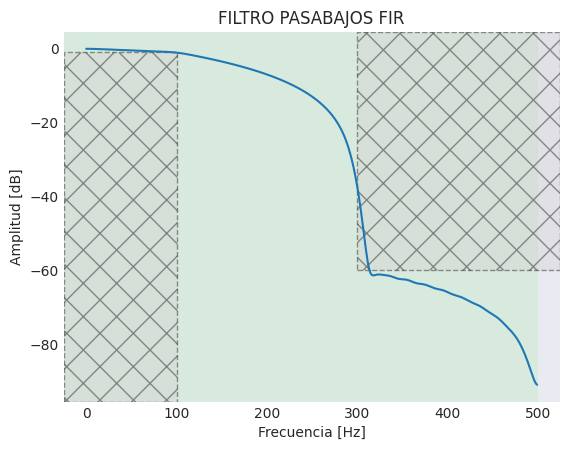

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Oct  3 23:08:47 2026

@author: keila
"""

import numpy as np
import scipy.signal as sp
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

# --- FILTRO A: PASABAJOS FIR ---
fp = 100     # Hz (frecuencia de paso)
fstop = 300  # Hz (frecuencia de detención)
alfa_max = 1 # dB
alfa_min = 60# dB
fs = 1000    # Hz (frecuencia de muestreo)

# IIR Chebyshev
system_a = sp.iirdesign(fp, fstop, alfa_max, alfa_min, ftype='cheby1', output='sos', fs=fs)
w_iir, h_iir = sp.freqz_sos(system_a, worN=1000, fs=fs)


N = 101
frecs = [0, fp, fstop, fs/2]
gains = [0, -alfa_max, -alfa_min, -np.inf]
gains = 10**(np.array(gains)/20)
bfir = sp.firwin2(N, frecs, gains, window='hamming', fs=fs)
w_fir, h_fir = sp.freqz(bfir, fs=fs)

mag_fir = 20 * np.log10(np.abs(h_fir))

plt.figure()
plt.plot(w_fir,mag_fir)

plt.title('FILTRO PASABAJOS FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')

plot_plantilla(filter_type = 'lowpass' , fpass = fp, ripple = alfa_max , fstop = fstop, attenuation = alfa_min, fs = fs)

print(f"Orden del filtro FIR = {len(bfir)}")

- Mirando el resultado de la plantilla, el filtro pasabajos FIR no cumple al 100% con los límites teóricos exigidos. Aunque no cumplió la plantilla perfectamente, la implementación en el kit funcionó sin problemas para validar el procesamiento de la señal.

#### ***Filtro B: Notch Digital IIR***

Orden Total del filtro Notch IIR = 8


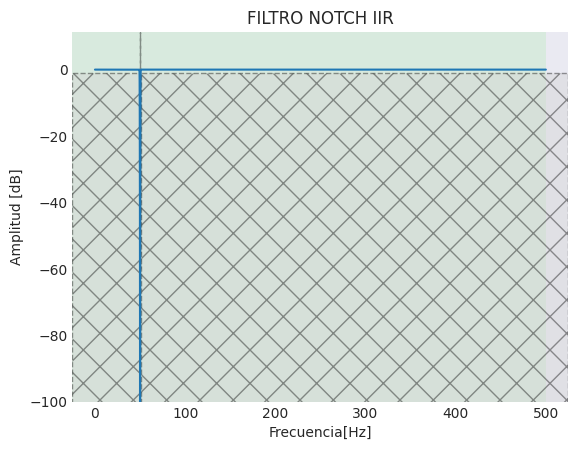

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Oct  3 23:08:47 2026

@author: keila
"""

import numpy as np
import scipy.signal as sp
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import plot_plantilla

# --- FILTRO B: NOTCH IIR ---
fnotch = 50  # Hz
BW = 1       # Hz
fpass = (fnotch - BW/2, fnotch + BW/2)
fstop_b = (fnotch - 0.05, fnotch + 0.05)

system_b = sp.iirdesign(fpass, fstop_b, 3, 60, ftype='butter', output='sos', fs=fs)
w_notch, h_notch = sp.freqz_sos(system_b, worN=10000, fs=fs)

plt.figure()

plt.plot(w_notch,20*np.log10(np.abs(h_notch)+ 1e-12))


plt.title('FILTRO NOTCH IIR')
plt.xlabel('Frecuencia[Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')

plot_plantilla(filter_type = 'bandstop' , fpass = fpass, ripple = alfa_max , fstop = fstop_b, attenuation = alfa_min, fs = fs)

print(f"Orden Total del filtro Notch IIR = {len(system_b) * 2}") #system_b es una matriz SOS donde cada fila es una sección de 2º orden

Coeficientes del *Filtro Notch IIR de orden 8*: [[0.9876471423021117, -1.8786196529406052, 0.9876471423021115, 1.0, -1.8903677129750165, 0.9876469052131024, ],
[1.0, -1.9021162239802782, 0.9999999999999998, 1.0, -1.8927552321046763, 0.9937022008774528, ],
[1.0, -1.9021162239802782, 0.9999999999999998, 1.0, -1.8995831289805998, 0.9939068047942485, ],
]

### ***Diseño de Filtros Analógicos de $Anti-Alias$ e $Interpolación$***

Para acondicionar la señal de entrada y pulir la salida del DAC, se utilizó una placa experimental con filtros pasabajos RC de primer orden:

<figure style="text-align: center;">
  <img src="filtros_PB_interpolacion.jpeg" alt="Descripción de la imagen" width="300">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 3: Filtro "Anti-alias" e "Interpolación" implementados en placa perforada.
  </figcaption>
</figure>

La función del *Filtro Anti-Alias* limpiar la señal que entra al ADC limando cualquier frecuencia por encima de la mitad de la frecuencia de muestreo, evitando que se solapen o aparezcan frecuencias "fantasmas". Con esto nos aseguramos de no meter ruido por aliasing y cumplir con la condición de Nyquist ($f_s/2$).
Por otro lado, el *Filtro de Interpolación* va a la salida del DAC para filtrar los "escalones" propios de la conversión digital y dejar la señal analógica reconstruida lo más suave y continua posible.

Para ello se implemento un:

- $C= 470nF$
- $R= 1.2k\ohm$

  De modo tal que:

  $$ f_c = \frac{1}{2 \pi \cdot R \cdot C} = \frac{1}{2 \pi \cdot 1200\,\Omega \cdot 470 \cdot 10^{-9}\,\text{F}} \approx \mathbf{282{,}18\text{ Hz}}$$

Siendo $f_c \approx 282\text{ Hz}$ un valor adecuado, ya que deja pasar sin atenuación significativa la banda de interés del filtro digital y atenúa adecuadamente las componentes cercanas o superiores al límite de Nyquist ($f_s / 2 = 500\text{ Hz}$).

Notar que ambos filtros se realizaron con los mismos componentes, es decir, se comportan igual.

##### ***Simulación en LTSpice***

<figure style="text-align: center;">
  <img src="spice1_antialias_interpolación.png" alt="Descripción de la imagen" width="500">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 4: Circuito en LTSpice del "Filtro Anti-Alias" e "Interpolación".
  </figcaption>
</figure>

<figure style="text-align: center;">
  <img src="spice_antialias_interpolación.png" alt="Descripción de la imagen" width="900">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 5: Simulación en LTSpice del "Filtro Anti-Alias" e "Interpolación".
  </figcaption>
</figure>

## ***Laboratorio***

### ***Mediciones con el osciloscopio***

Se contrastaron las mediciones tomadas en el laboratorio mediante osciloscopio:

<figure style="text-align: center;">
  <img src="medicionesLab.png" alt="Descripción de la imagen" width="500">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 6: Valores medidos en osciloscopio de tensión de entrada ($V_\text{in}$) y salida ($V_\text{out}$) para el filtro Notch IIR (izquierda) y el filtro pasabajos FIR (derecha).
  </figcaption>
</figure>

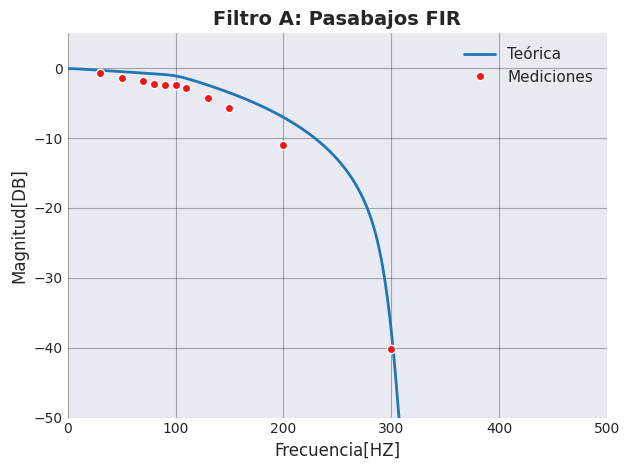

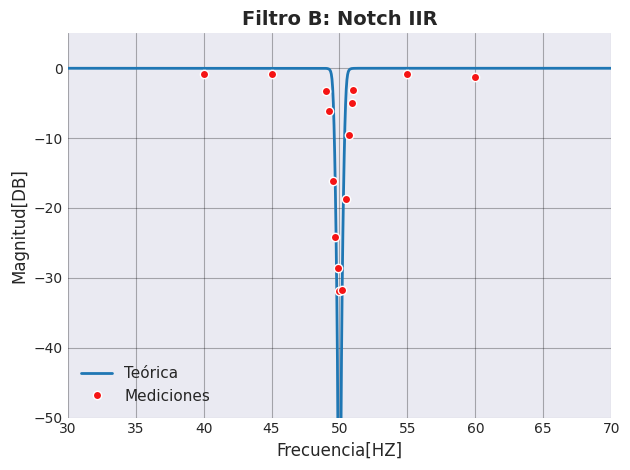

In [11]:
import matplotlib.pyplot as plt
from scipy import signal as sig

plt.style.use('seaborn-v0_8-darkgrid')


# --- FILTRO A: PASABAJOS CHEBYSHEV FIR ---
f = np.array([30,50,70,80,90,100,110,130,150,200,300])
V_in = np.array([2.11,2.20,2.15,2.16,2.16,2.11,2.1,2.07,2.07,2.05,2.05])
V_out = np.array([1.96,1.87,1.75,1.67,1.63,1.60,1.51,1.27,1.08,0.576,0.02])

T = 20 * np.log10(V_out / V_in)

fig, ax1 = plt.subplots()

ax1.plot(w_fir,mag_fir, label='Teórica', linewidth=2)
ax1.plot(f, T, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax1.set_xlabel('Frecuencia[HZ]', fontsize=12)
ax1.set_ylabel('Magnitud[DB]', fontsize=12)
ax1.set_title('Filtro A: Pasabajos FIR', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, which='both',color='black', alpha=0.3)
ax1.tick_params(labelsize=10)

ax1.set_xlim([0, 500])

ax1.set_ylim([-50, 5])

plt.tight_layout()
plt.show()

# --- FILTRO B: NOTCH IIR ---
f = np.array([40,45,49,49.2,49.5,49.7,49.9,50,50.2,50.5,50.7,50.9,51,55,60])
V_in = np.array([3.35,3.27,3.27,3.16,3.35,3.24,3.24,3.16,3.11,3.11,3.11,3.03,3.11,3.27,3.31])
V_out = np.array([3.03,2.96,2.24,1.55,520e-3,200e-3,120e-3,80e-3,80e-3,360e-3,1.03,1.72,2.16,2.96,2.88])

T = 20 * np.log10(V_out / V_in)

fig, ax1 = plt.subplots()

ax1.plot(w_notch, 20*np.log10(np.abs(h_notch)), label='Teórica', linewidth=2)
ax1.plot(f, T, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax1.set_xlabel('Frecuencia[HZ]', fontsize=12)
ax1.set_ylabel('Magnitud[DB]', fontsize=12)
ax1.set_title('Filtro B: Notch IIR', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, which='both',color='black', alpha=0.3)
ax1.tick_params(labelsize=10)

ax1.set_xlim([30, 70])

ax1.set_ylim([-50, 5])

plt.tight_layout()
plt.show()


#### ***Medición del módulo del Filtro A: Pasabajos FIR***

<figure style="text-align: center;">
  <img src="1000218969.jpg" alt="Descripción de la imagen" width="900">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 7: Curva de respuesta en frecuencia medida en analizador para el filtro pasabajos FIR.
  </figcaption>
</figure>

Se observa la atenuación de la banda de paso y la transición hacia la banda de detención, destacando en el *Marcador 1* una atenuación de más o menos $-60\text{ dB}$ a aproximadamente $360\text{ Hz}$, lo que valida el cumplimiento del requerimiento de $\alpha_{min} = 60\text{ dB}$ de la plantilla.

## ***Conclusión***

En conclusión, las comprobaciones experimentales en el laboratorio permitieron validar la respuesta de ambos filtros frente a sus modelos teóricos y simulaciones previas. Por un lado, el filtro pasabajos FIR logró la transición deseada, alcanzando los $60\text{ dB}$ de atenuación en la banda de detención verificados en las imágenes expuestas. Por otro lado, la implementación del Notch IIR logró sintonizar la muesca en los $50\text{ Hz}$, atenuando eficazmente la misma. 